In [3]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data (1).csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
df = pd.read_csv('data (1).csv')
print("Shape:", df.shape)
print(df.head())

Shape: (511, 14)
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [7]:
X = df.drop('MEDV', axis=1)  # Features (input)
y = df['MEDV']               # Target (output - ghar ki price)
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (511, 13)
Target shape: (511,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 408
Testing samples: 103


In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load + NaN fix
df = pd.read_csv('data (1).csv')
df = df.fillna(df.mean())

# Features & Target
X = df.drop('MEDV', axis=1)
y = df['MEDV']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train, y_train)
print("Model trained successfully! ✅")

# Results
y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

Model trained successfully! ✅
R2 Score: 0.3053597956485078
MSE: 59.532908737864076


In [12]:
y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.3053597956485078
MSE: 59.532908737864076


In [13]:
# Better K value dhundho
from sklearn.preprocessing import StandardScaler

# Scaling karo (KNN ke liye zaroori hai)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Naya model better K ke saath
model2 = KNeighborsRegressor(n_neighbors=3)
model2.fit(X_train_scaled, y_train)

y_pred2 = model2.predict(X_test_scaled)
print("Improved R2 Score:", r2_score(y_test, y_pred2))
print("Improved MSE:", mean_squared_error(y_test, y_pred2))

Improved R2 Score: 0.5827607789155813
Improved MSE: 35.758748651564176


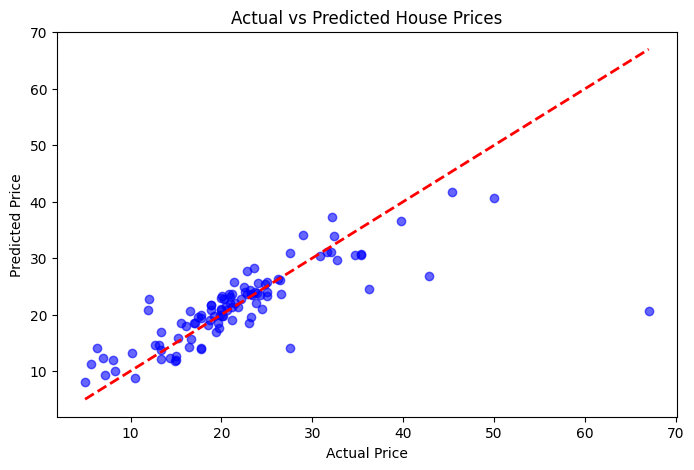

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred2, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()